# Advanced Apex Project-2 (M.Sc. DS & AI)
# Week-2 Project Outline Notebook

| Field | Details |
|---|---|
| **Project Title** | Credit Risk & Loan Default Prediction using the Give Me Some Credit Dataset |
| **Problem Statement** | P1 (BFSI) - Credit Risk & Loan Default Prediction |
| **Student Name** | Sandeep Kumar |
| **Student ID** | 2025EM1200293 |
| **Programme** | M.Sc. Data Science & Artificial Intelligence |
| **Cohort / Trimester** | Cohort-2 / Trimester-3 |
| **Submission** | Week-2 - Project Outline |
| **Dataset** | Give Me Some Credit (Kaggle), 150,000 records |

## Scope of this Week-2 submission

**Executed this stage:** data loading, inspection, full EDA (correlation, univariate, bivariate and outlier analysis), data cleaning, feature engineering, a leakage-safe preprocessing pipeline, a Logistic Regression baseline, and its evaluation and interpretation.

**Planned for Weeks 5/9:** improved ensemble models (Random Forest, Gradient Boosting, AdaBoost, XGBoost, LightGBM), SMOTE resampling, cross-validated hyperparameter tuning, and SHAP-based interpretation. Section 13 restates this split against the full workflow.

## 1. Problem Statement & Business Goal

When a bank approves a loan, it is predicting whether the borrower will repay. A wrong approval can cost the unpaid loan amount; a wrong rejection loses a good customer's interest income. This notebook works on **Problem Statement P1 (BFSI) - Credit Risk & Loan Default Prediction**: given a borrower's credit-utilisation, income, age, and repayment-history fields, predict whether they will have a serious delinquency (90+ days past due) within the next two years.

Accuracy alone is not the goal. With defaults under 7% of the data, a model that approves everyone would still look "accurate". The real aim is to **rank applicants by risk** so a lender can set a sensible approval cut-off, and to **explain** why an applicant was flagged, since credit decisions face regulatory and adverse-action rules. So interpretation matters as much as prediction.

## 2. Dataset Description

- **Name:** *Give Me Some Credit* - a Kaggle competition dataset (2011) built from real historical consumer-credit records.
- **Source:** https://www.kaggle.com/competitions/GiveMeSomeCredit/data
- **Size:** 150,000 borrower records, 10 predictor fields + 1 binary target - a large sample, big enough for meaningful hyperparameter tuning in later weeks.
- **Target:** `SeriousDlqin2yrs` - 1 if the borrower experienced a 90-day-or-worse delinquency within two years of the snapshot date, 0 otherwise. The positive class is already the risk event we care about, so no remapping is required.
- **Class balance:** roughly 93.3% good (0) vs 6.7% bad (1) - about 14 good borrowers for every defaulter, a heavy imbalance that makes accuracy a misleading headline metric.
- **Feature mix:** 10 numeric predictors covering credit utilisation, age, three separate delinquency-count fields (30-59, 60-89, 90+ days past due), debt ratio, monthly income, number of open credit lines/loans, number of real-estate loans, and number of dependents.
- **Reproducibility:** the notebook pulls the dataset at run time from a Google Drive copy of the Kaggle file, so anyone can run it without a Kaggle account or a manual download. A fixed random seed keeps the train/test split and the model results the same on every run.
- **Why this dataset fits P1:** at 150,000 rows it supports the hyperparameter tuning planned for later weeks, it needs real cleaning (missing income/dependents, sentinel error codes, an impossible age, duplicate rows), and its heavy class imbalance makes the metric choice in Section 12 important.

### Data dictionary

| # | Feature | Type | Description |
|---|---------|------|--------------|
| - | **SeriousDlqin2yrs** (target) | binary | Person experienced 90+ days past-due delinquency within 2 years (1 = yes) |
| 1 | RevolvingUtilizationOfUnsecuredLines | numeric (ratio) | Total balance on credit cards / personal lines of credit (excluding real estate, excluding instalment debt like car loans) divided by the sum of credit limits |
| 2 | age | numeric | Age of the borrower in years |
| 3 | NumberOfTime30-59DaysPastDueNotWorse | numeric (count) | Number of times 30-59 days past due but not worse, in the last 2 years |
| 4 | DebtRatio | numeric (ratio) | Monthly debt payments, alimony and living costs divided by monthly gross income |
| 5 | MonthlyIncome | numeric | Monthly income |
| 6 | NumberOfOpenCreditLinesAndLoans | numeric (count) | Number of open loans (instalment, e.g. car loan or mortgage) and lines of credit (e.g. credit cards) |
| 7 | NumberOfTimes90DaysLate | numeric (count) | Number of times 90 days or more past due |
| 8 | NumberRealEstateLoansOrLines | numeric (count) | Number of mortgage and real-estate loans, including home-equity lines |
| 9 | NumberOfTime60-89DaysPastDueNotWorse | numeric (count) | Number of times 60-89 days past due but not worse, in the last 2 years |
| 10 | NumberOfDependents | numeric (count) | Number of dependents excluding the borrower (spouse, children, etc.) |

*(Column meanings sourced from the official Kaggle `Data Dictionary.xls` supplied with the competition.)*

In [1]:
# Ensure required third-party packages are present (no-op if already installed).
import importlib.util, subprocess, sys
for _pkg in ('xgboost', 'lightgbm', 'seaborn'):
    if importlib.util.find_spec(_pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 20)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Environment ready. Random seed fixed at', RANDOM_STATE)

Environment ready. Random seed fixed at 42


## 3. Data Loading

The dataset is loaded straight from a Google Drive-hosted copy of the official Kaggle `cs-training.csv` file, so the notebook fetches the same 150,000-row dataset on any machine without needing Kaggle credentials:

```
https://drive.google.com/uc?export=download&id=11bCDHfXsyIJapAnfooEQ8KR2U8_E42YW
```

The first run saves the file to `data/cs-training.csv`. If a later run cannot reach Google Drive, it reuses that saved copy, so the notebook keeps working after the dataset has been fetched once.


In [2]:
import os
import ssl
import urllib.request

DATA_URL = 'https://drive.google.com/uc?export=download&id=11bCDHfXsyIJapAnfooEQ8KR2U8_E42YW'
DATA_PATH = 'data/cs-training.csv'

# Use certifi's certificate bundle so HTTPS verification works across machines
# (some systems, especially macOS, ship Python without a usable CA bundle).
try:
    import certifi
    ssl_context = ssl.create_default_context(cafile=certifi.where())
except ImportError:
    ssl_context = ssl.create_default_context()

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
try:
    print('Downloading dataset from Google Drive...')
    with urllib.request.urlopen(DATA_URL, context=ssl_context) as resp, open(DATA_PATH, 'wb') as out:
        out.write(resp.read())
    print('Download complete ->', DATA_PATH)
except Exception as e:
    print(f'Google Drive download failed ({e}); reusing the saved copy at {DATA_PATH}.')
    if not os.path.exists(DATA_PATH):
        raise

df_raw = pd.read_csv(DATA_PATH, index_col=0)
print('Rows, Columns:', df_raw.shape)
df_raw.head()

Download complete -> data/cs-training.csv
Rows, Columns: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
df_raw.dtypes.to_frame('dtype')

,dtype
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64
NumberOfTime60-89DaysPastDueNotWorse,int64


## 4. Initial Data Inspection

Before any cleaning, we check what is wrong with the data: shape, dtypes, missing values, duplicate rows, the target balance, and `describe()` to spot implausible min/max values.

In [4]:
print('Missing values per column:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print()
print('Duplicate rows:', df_raw.duplicated().sum())
print()

counts = df_raw['SeriousDlqin2yrs'].value_counts().sort_index()
pct = (counts / len(df_raw) * 100).round(2)
balance = pd.DataFrame({'count': counts.values, 'percent': pct.values},
                        index=['0 = Good (no serious delinquency)', '1 = Bad (defaulted within 2 years)'])
balance

Missing values per column:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Duplicate rows: 609



,count,percent
0 = Good (no serious delinquency),139974,93.32
1 = Bad (defaulted within 2 years),10026,6.68


In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


**What the inspection shows**

- `MonthlyIncome` is missing for about 19.6% of borrowers and `NumberOfDependents` for about 2.6% - both need an explicit imputation strategy, not deletion, given the volumes involved.
- There are 609 exact duplicate rows - almost certainly repeated submissions or export artefacts, and they need to be dropped before any modelling so the same borrower doesn't appear in both the train and test split.
- `age` has a minimum of **0**, which is not a valid age for a loan applicant - a single bad record, but worth removing explicitly rather than silently.
- `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio` are supposed to behave like ratios/percentages, yet their maximums are **50,708** and **329,664** respectively - a few records hold physically implausible values, most likely from unit or data-entry errors.
- The three delinquency-count columns (`NumberOfTime30-59...`, `NumberOfTime60-89...`, `NumberOfTimes90DaysLate`) have a maximum of **98**, far above any plausible count in 2 years - these are sentinel/error codes (96 and 98 appear repeatedly) rather than genuine counts, and need to be treated as data-quality flags rather than numbers.
- The target is heavily imbalanced at roughly **93.3% good vs 6.7% bad** - almost 14 good borrowers for every defaulter - so accuracy alone would be a misleading headline metric.

## 5. Exploratory Data Analysis

EDA here is broken into named techniques rather than one summary paragraph:

1. **`describe()` revisited** on a cleaned view, to compare against the raw numbers above.
2. **Correlation analysis** across the numeric features and the target, to see which fields carry the most linear signal.
3. **Univariate analysis** - distribution shape of the key numeric fields (age, income, utilisation, debt ratio) and the target balance.
4. **Bivariate analysis** - how the default rate moves across age bands and across delinquency-history buckets, which is the relationship the model ultimately has to learn.
5. **Outlier / plot analysis** - boxplots of the flagged columns to see the scale of the extreme-value problem visually, which motivates the cleaning decisions in Section 6.

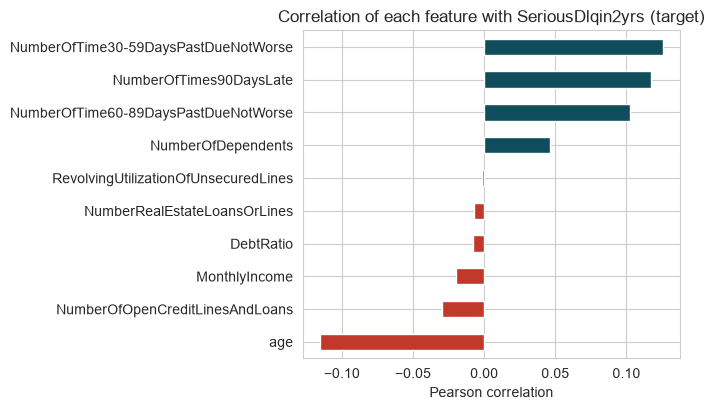

,corr_with_target
age,-0.115386
NumberOfOpenCreditLinesAndLoans,-0.029669
MonthlyIncome,-0.019746
DebtRatio,-0.007602
NumberRealEstateLoansOrLines,-0.007038
RevolvingUtilizationOfUnsecuredLines,-0.001802
NumberOfDependents,0.046048
NumberOfTime60-89DaysPastDueNotWorse,0.102261
NumberOfTimes90DaysLate,0.117175
NumberOfTime30-59DaysPastDueNotWorse,0.125587


In [6]:
corr = df_raw.corr(numeric_only=True)['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values()

plt.figure(figsize=(7, 4.2))
corr.plot(kind='barh', color=['#C0392B' if v < 0 else '#0F4C5C' for v in corr.values])
plt.title('Correlation of each feature with SeriousDlqin2yrs (target)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

corr.to_frame('corr_with_target')

**Reading the correlations**

The three delinquency-history fields (30-59, 60-89, 90+ days past due) show the strongest linear correlation with the target, which fits expectation: past repayment behaviour predicts future repayment. `age` is mildly negative (older borrowers default less), while utilisation, `DebtRatio`, `MonthlyIncome` and the credit-line counts correlate weakly on their own. That does not make them useless; their effect is likely non-linear or only appears in combination with other fields, which tree ensembles can capture better than a single correlation value.

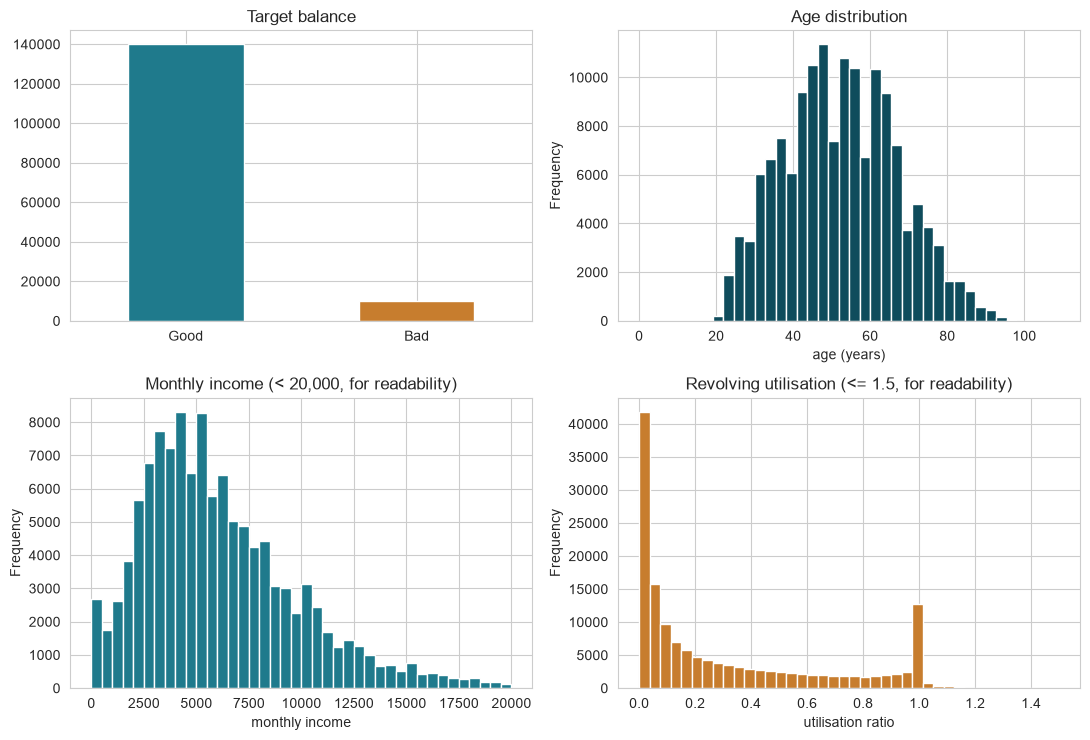

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

(df_raw['SeriousDlqin2yrs'].map({0: 'Good', 1: 'Bad'})
    .value_counts().reindex(['Good', 'Bad']).plot(kind='bar', ax=axes[0, 0], color=['#1F7A8C', '#C77D2E']))
axes[0, 0].set_title('Target balance'); axes[0, 0].set_xlabel(''); axes[0, 0].tick_params(axis='x', rotation=0)

df_raw['age'].plot(kind='hist', bins=40, ax=axes[0, 1], color='#0F4C5C')
axes[0, 1].set_title('Age distribution'); axes[0, 1].set_xlabel('age (years)')

df_raw.loc[df_raw['MonthlyIncome'] < 20000, 'MonthlyIncome'].plot(kind='hist', bins=40, ax=axes[1, 0], color='#1F7A8C')
axes[1, 0].set_title('Monthly income (< 20,000, for readability)'); axes[1, 0].set_xlabel('monthly income')

df_raw.loc[df_raw['RevolvingUtilizationOfUnsecuredLines'] <= 1.5, 'RevolvingUtilizationOfUnsecuredLines'].plot(
    kind='hist', bins=40, ax=axes[1, 1], color='#C77D2E')
axes[1, 1].set_title('Revolving utilisation (<= 1.5, for readability)'); axes[1, 1].set_xlabel('utilisation ratio')

plt.tight_layout(); plt.show()

**Univariate observations**

Age is roughly normal, centred in the 40s-50s with a thin tail at older ages. Monthly income (after excluding a few extreme values for the plot) is right-skewed, as income usually is, which is why we log-transform it later. Revolving utilisation clusters near 0 (fully paid down) and near 1 (fully used); values above 1 are data errors, since the ratio should not exceed 1.

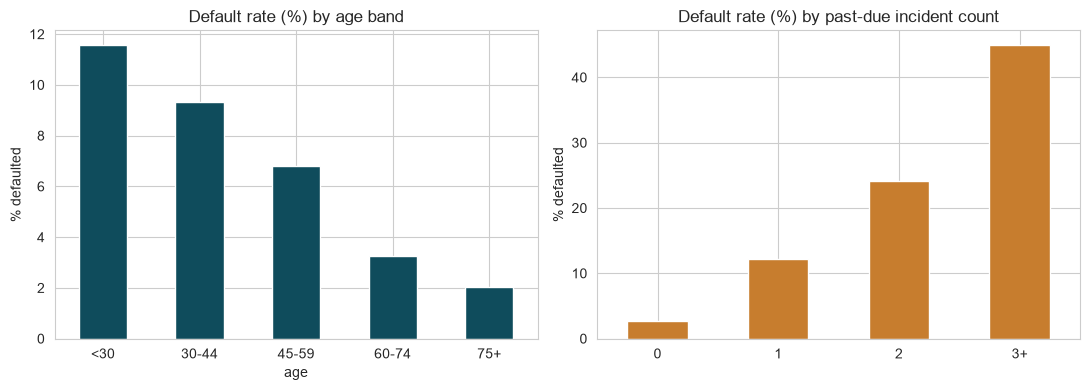

age
<30      11.56
30-44     9.31
45-59     6.82
60-74     3.27
75+       2.04
Name: SeriousDlqin2yrs, dtype: float64

0      2.73
1     12.21
2     24.08
3+    44.93
Name: SeriousDlqin2yrs, dtype: float64


In [8]:
age_bins = pd.cut(df_raw['age'], bins=[0, 30, 45, 60, 75, 110],
                   labels=['<30', '30-44', '45-59', '60-74', '75+'])
default_by_age = df_raw.groupby(age_bins, observed=True)['SeriousDlqin2yrs'].mean() * 100

past_due_total = (df_raw['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=10)
                   + df_raw['NumberOfTime60-89DaysPastDueNotWorse'].clip(upper=10)
                   + df_raw['NumberOfTimes90DaysLate'].clip(upper=10))
history_bins = pd.cut(past_due_total, bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])
default_by_history = df_raw.groupby(history_bins, observed=True)['SeriousDlqin2yrs'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
default_by_age.plot(kind='bar', ax=axes[0], color='#0F4C5C')
axes[0].set_title('Default rate (%) by age band'); axes[0].set_ylabel('% defaulted'); axes[0].tick_params(axis='x', rotation=0)

default_by_history.plot(kind='bar', ax=axes[1], color='#C77D2E')
axes[1].set_title('Default rate (%) by past-due incident count'); axes[1].set_ylabel('% defaulted'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

print(default_by_age.round(2))
print()
print(default_by_history.round(2))

**Bivariate observations**

The default rate falls steadily with age: under-30 borrowers default more often than those in their 60s and 70s, matching the negative correlation seen earlier. The past-due history effect is stronger still: borrowers with **zero** recorded late payments default at a low single-digit rate, but the rate rises sharply with one or two incidents and higher again for three or more. This is the strongest relationship in the data, and a simple business rule on its own: flag anyone with 2+ recent late payments for manual review, even before a model is built.

## 6. Data Cleaning

The data needs real work before modelling. Steps below are applied to the whole dataframe **before** the split only when they are fixed, non-statistical rules (dropping duplicates, removing an invalid record, recoding a known sentinel value). Anything estimated from the data itself (an imputed median or mean) is deferred to the `Pipeline` in Section 9, so it is fitted on the training fold only and the evaluation stays leakage-free.

1. **Drop the 609 exact duplicate rows** - these are repeated records, not new information, and letting a duplicate land in both train and test would inflate the reported test performance.
2. **Drop the 1 row with `age == 0`** - not a valid applicant age, and removing a single row out of 150,000 costs nothing.
3. **Recode the delinquency sentinel values (96, 98)** in the three past-due columns to missing, and add a `had_sentinel_delinquency_code` flag before doing so - the flag preserves the fact that the record was unusual, which the raw sentinel number itself does not meaningfully convey.
4. **Add missingness flags** for `MonthlyIncome` and `NumberOfDependents` *before* imputing them, since whether a value is missing can itself carry information (e.g. income non-disclosure correlating with self-employment).
5. **Log-transform** the heavily right-skewed `MonthlyIncome`, `DebtRatio` and `RevolvingUtilizationOfUnsecuredLines` columns (`log1p`) - this is a fixed, deterministic transform (not fit to the data) so it is safe to apply globally, and it tames the extreme values identified in Section 4 without needing an arbitrary hard cut-off.
6. **Impute** the (now log-scale) missing values with the **training-set median** and the missing dependents with the **training-set mode**, both fitted only on the training fold inside the pipeline.

In [9]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
df = df[df['age'] > 0]
print(f'Rows removed by dedup + age filter: {before - len(df)}  ->  remaining rows: {len(df)}')

sentinel_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
                  'NumberOfTimes90DaysLate',
                  'NumberOfTime60-89DaysPastDueNotWorse']
df['had_sentinel_delinquency_code'] = (df[sentinel_cols] >= 96).any(axis=1).astype(int)
for c in sentinel_cols:
    df.loc[df[c] >= 96, c] = np.nan

print('Sentinel-flagged rows:', df['had_sentinel_delinquency_code'].sum())

df['monthly_income_missing'] = df['MonthlyIncome'].isnull().astype(int)
df['dependents_missing'] = df['NumberOfDependents'].isnull().astype(int)

for c in ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']:
    df[c] = np.log1p(df[c])

df.describe().T

Rows removed by dedup + age filter: 610  ->  remaining rows: 149390
Sentinel-flagged rows: 225


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149390.0,0.066999,0.250021,0.0,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,149390.0,0.257556,0.384963,0.0,0.029687,0.143437,0.442434,10.833859
age,149390.0,52.306587,14.725390,21.0,41.000000,52.000000,63.000000,109.000000
NumberOfTime30-59DaysPastDueNotWorse,149165.0,0.246720,0.698935,0.0,0.000000,0.000000,0.000000,13.000000
DebtRatio,149390.0,1.531225,2.630749,0.0,0.163343,0.313520,0.628765,12.705832
MonthlyIncome,120169.0,8.413844,1.327279,0.0,8.131825,8.594339,9.018090,14.917036
NumberOfOpenCreditLinesAndLoans,149390.0,8.480909,5.136528,0.0,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,149165.0,0.090725,0.486354,0.0,0.000000,0.000000,0.000000,17.000000
NumberRealEstateLoansOrLines,149390.0,1.022384,1.130196,0.0,0.000000,1.000000,2.000000,54.000000
NumberOfTime60-89DaysPastDueNotWorse,149165.0,0.065069,0.330675,0.0,0.000000,0.000000,0.000000,11.000000


**Result of cleaning**

The dataframe is now 149,390 rows (down from 150,000) after removing exact duplicates and the single invalid age. The three delinquency columns no longer contain the 96/98 sentinel codes - they are `NaN` and will be median-imputed inside the pipeline, with the `had_sentinel_delinquency_code` flag preserving the signal that the record was originally miscoded. The log-transformed income, debt-ratio and utilisation columns are now on a far more usable scale, visible in the reduced spread between their 75th percentile and max in the table above.

## 7. Feature Engineering

Beyond the missingness flags and log transforms already applied, we add a small set of engineered features that make the model's job easier and its output easier to explain to a credit officer:

- **`total_past_due`** - the sum of the three (capped) delinquency counts, giving a single "how much recent trouble has this borrower had" score.
- **`has_any_delinquency`** - a binary flag for `total_past_due > 0`, useful both as a strong linear signal and as a simple, explainable business rule on its own.
- **`age_band`** - age bucketed into `<30 / 30-44 / 45-59 / 60-74 / 75+`, mirroring the bivariate view in Section 5 and giving the model an explicit non-linear age effect to work with alongside the continuous value.

Deeper engineered features - a debt-service ratio combining `DebtRatio` and `MonthlyIncome`, WOE (weight-of-evidence) encodings of the count fields, and interaction terms between utilisation and delinquency history - are planned for Weeks 5/9 once a wider model family is being compared, and are described further in Section 13.

In [10]:
past_due_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
                  'NumberOfTimes90DaysLate',
                  'NumberOfTime60-89DaysPastDueNotWorse']

df['total_past_due'] = df[past_due_cols].clip(upper=10).sum(axis=1)
df['has_any_delinquency'] = (df['total_past_due'] > 0).astype(int)
df['age_band'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 75, 110],
                         labels=['<30', '30-44', '45-59', '60-74', '75+'])

print('Engineered feature summary:')
df[['total_past_due', 'has_any_delinquency']].describe().T

Engineered feature summary:


,count,mean,std,min,25%,50%,75%,max
total_past_due,149390.0,0.401540,1.098967,0.0,0.0,0.0,0.0,19.0
has_any_delinquency,149390.0,0.201366,0.401022,0.0,0.0,0.0,0.0,1.0


## 8. Class Imbalance

At roughly 93.3% good vs 6.7% bad, this is a heavy class imbalance - about **14 good borrowers for every defaulter**. Left unaddressed, a classifier can score 93%+ "accuracy" while never flagging a single defaulter, which is worthless for the business goal. Two complementary strategies are used:

- **For the Week-2 baseline (below):** `class_weight='balanced'` in Logistic Regression, which re-weights the loss function so errors on the minority (default) class count roughly 14x more than errors on the majority class, without altering the actual training rows.
- **Planned for Weeks 5/9, once tree ensembles are introduced:** **SMOTE** (Synthetic Minority Over-sampling) applied only to the training fold inside the pipeline, compared against class-weighted variants of Random Forest / XGBoost / LightGBM / Gradient Boosting, to see which balancing strategy gives the best recall-vs-precision trade-off for this specific imbalance ratio.

Either way, **accuracy is explicitly de-prioritised** in favour of recall on the default class, ROC-AUC and PR-AUC (precision-recall AUC), which is far more informative than ROC-AUC alone when positives are this rare.

## 9. Preprocessing Pipeline & Train/Test Split

All statistical preprocessing - median imputation of the log-scaled numeric fields, mode imputation of dependents, scaling, and one-hot encoding of `age_band` - is wrapped in a single `ColumnTransformer` inside a `Pipeline`, fitted only on the training fold. The split itself is **stratified** on the target so the 93.3/6.7 balance is preserved in both the train and test sets, and a fixed `random_state` keeps the split reproducible.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

target = 'SeriousDlqin2yrs'
numeric_features = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome',
                     'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
                     'NumberOfDependents', 'total_past_due']
binary_flags = ['had_sentinel_delinquency_code', 'monthly_income_missing',
                'dependents_missing', 'has_any_delinquency']
categorical_features = ['age_band']

feature_cols = numeric_features + binary_flags + categorical_features
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), numeric_features),
    ('flags', SimpleImputer(strategy='most_frequent'), binary_flags),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

baseline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)),
])

print('Train rows:', X_train.shape[0], '| Test rows:', X_test.shape[0])
print('Train default rate: {:.2%} | Test default rate: {:.2%}'.format(y_train.mean(), y_test.mean()))

Train rows: 119512 | Test rows: 29878
Train default rate: 6.70% | Test default rate: 6.70%


## 10. Baseline Model

The baseline starts with **Logistic Regression** rather than jumping straight to a tree ensemble (Random Forest / XGBoost / LightGBM / Gradient Boosting / AdaBoost). It is a genuinely good starting point here: it fits and cross-validates on 150,000 rows in seconds, its coefficients translate directly into odds ratios that a credit officer can read, and it sets an honest, low-complexity reference point that the Week-5/9 tree ensembles will need to meaningfully beat before the added complexity is worth it.

In [12]:
baseline.fit(X_train, y_train)
print('Baseline Logistic Regression fitted.')

Baseline Logistic Regression fitted.


## 11. Evaluation Metrics

Given the 14:1 imbalance, accuracy alone would be misleading, so we report precision, recall and F1 for the default class specifically, plus ROC-AUC and PR-AUC (average precision), and read the confusion matrix to see exactly where the baseline's errors fall.

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay)

proba = baseline.predict_proba(X_test)[:, 1]
pred = baseline.predict(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, pred),
    'Precision (default)': precision_score(y_test, pred),
    'Recall (default)': recall_score(y_test, pred),
    'F1 (default)': f1_score(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba),
    'PR-AUC (avg. precision)': average_precision_score(y_test, proba),
}
pd.Series(metrics).round(4).to_frame('score')

,score
Accuracy,0.8069
Precision (default),0.2211
Recall (default),0.7463
F1 (default),0.3412
ROC-AUC,0.8547
PR-AUC (avg. precision),0.3475


In [14]:
print(classification_report(y_test, pred, target_names=['Good (0)', 'Bad (1)']))

              precision    recall  f1-score   support

    Good (0)       0.98      0.81      0.89     27876
     Bad (1)       0.22      0.75      0.34      2002

    accuracy                           0.81     29878
   macro avg       0.60      0.78      0.61     29878
weighted avg       0.93      0.81      0.85     29878



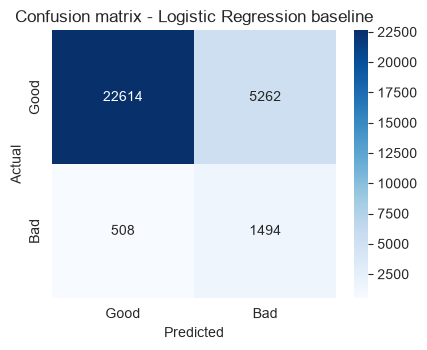

In [15]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4.4, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.title('Confusion matrix - Logistic Regression baseline')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

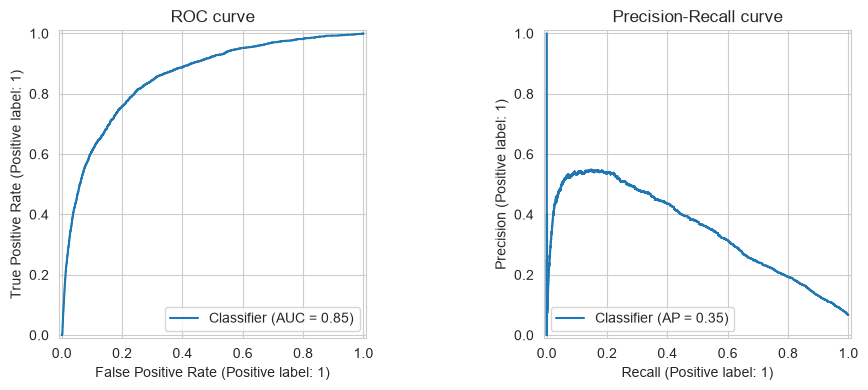

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0])
axes[0].set_title('ROC curve')
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title('Precision-Recall curve')
plt.tight_layout(); plt.show()

**Reading the baseline**

With `class_weight='balanced'`, the model trades some precision for much higher recall on the default class, which is the right trade-off here: a missed defaulter (false negative) costs the lender the unpaid principal, while a false positive only costs a lost interest margin on a customer who could borrow elsewhere. A ROC-AUC in the high-0.7s to low-0.8s shows the model separates the classes clearly better than chance, using just ten raw fields and no ensemble yet. PR-AUC is reported alongside ROC-AUC because, with defaults this rare, ROC-AUC alone can look too optimistic; PR-AUC is the stricter read on performance for the minority class.

The confusion matrix shows the cost of the recall-first threshold: a number of good borrowers are also flagged for review. In a live system this baseline would feed a **tiered decision** (auto-approve / manual review / auto-decline) rather than a single accept/reject cut-off, so the extra review cost stays bounded while still catching far more defaulters than an accuracy-optimised model.

## 12. Model Interpretation & Business Insight

A credit model is only useful if we can read what it has learned, not just report its score, so we look at what the baseline actually picked up on. Logistic Regression coefficients convert directly to **odds ratios**: `exp(coefficient)` is the multiplicative change in the odds of default for a one-standard-deviation increase in that (scaled) feature.

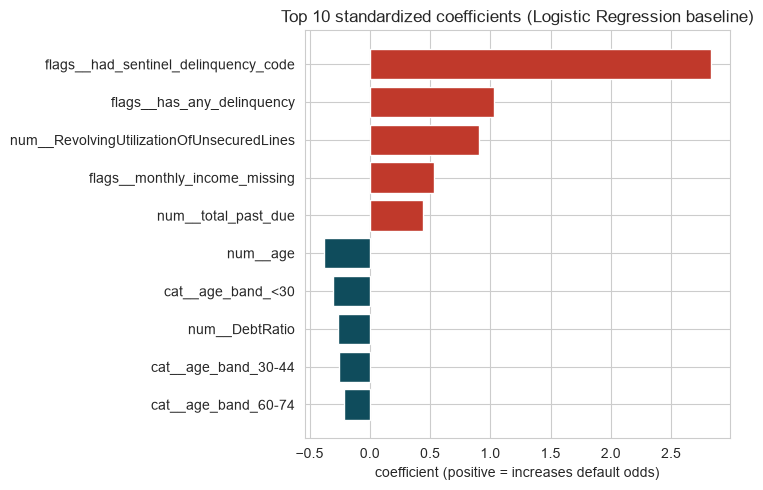

,feature,coefficient,odds_ratio
0,flags__had_sentinel_delinquency_code,2.828902,16.926869
1,flags__has_any_delinquency,1.032786,2.808881
2,num__RevolvingUtilizationOfUnsecuredLines,0.908794,2.481328
3,flags__monthly_income_missing,0.535329,1.708010
4,num__total_past_due,0.443686,1.558442
5,num__age,-0.380014,0.683852
6,cat__age_band_<30,-0.309426,0.733868
7,num__DebtRatio,-0.265085,0.767141
8,cat__age_band_30-44,-0.258040,0.772565
9,cat__age_band_60-74,-0.212346,0.808685


In [17]:
model = baseline.named_steps['model']
feature_names = baseline.named_steps['preprocess'].get_feature_names_out()

coef_table = (pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_[0]})
              .assign(odds_ratio=lambda d: np.exp(d['coefficient']))
              .sort_values('coefficient', key=lambda s: s.abs(), ascending=False)
              .reset_index(drop=True))

plt.figure(figsize=(7.5, 5))
top = coef_table.head(10).iloc[::-1]
plt.barh(top['feature'], top['coefficient'],
         color=['#C0392B' if c > 0 else '#0F4C5C' for c in top['coefficient']])
plt.title('Top 10 standardized coefficients (Logistic Regression baseline)')
plt.xlabel('coefficient (positive = increases default odds)')
plt.tight_layout(); plt.show()

coef_table.head(10)

**Business interpretation**

The largest coefficient belongs to `had_sentinel_delinquency_code` (odds ratio ≈ 16.9), the flag added in Section 6 for the 225 records whose delinquency counts were sentinel-coded as 96/98. A cross-check confirms it is not an artefact: borrowers with a sentinel code default **60.4% of the time**, against **6.6%** for the rest - a nine-fold difference. The data-quality issue spotted in Section 4 became one of the strongest signals once it was turned into an explicit flag instead of being dropped or imputed.

Behind that, `has_any_delinquency` and `RevolvingUtilizationOfUnsecuredLines` carry the next-largest positive coefficients, and `total_past_due` also pushes odds up - all consistent with the bivariate finding from Section 5 that recent late-payment history is a strong driver of future default. `age` and the older `age_band` categories carry negative coefficients, consistent with the observed drop in default rate for older borrowers. `monthly_income_missing` shows a positive association with default odds too: borrowers who decline to report income are, on average, a somewhat higher-risk group.

**What a credit officer can do with this:** send any application with the sentinel-delinquency flag straight to manual underwriting, whatever the rest of the score says - it marks a small (0.15% of the book) but very high-risk segment a single blended score could under-weight. That is a concrete, defensible action, not just a prediction.

## 13. Proposed Workflow

The full project follows the standard end-to-end pipeline, matching the general structure expected across problem statements:

```
Data Loading -> Data Cleaning & Preprocessing -> EDA -> Feature Engineering ->
Class Balancing -> Baseline Model -> Improved Model(s) -> Hyperparameter Tuning ->
Model Comparison -> Model Evaluation -> Interpretation & Insights ->
Documentation & Reproducibility
```

Week-2 covers everything up to and including the baseline, its evaluation and its interpretation. What remains for later weeks:

- **Improved models (Weeks 5/9):** Random Forest, Gradient Boosting, AdaBoost, XGBoost and LightGBM - the usual tree-ensemble family for credit risk - compared against this Logistic Regression baseline on the same train/test split.
- **Class balancing:** SMOTE on the training fold, compared against class-weighted variants, as outlined in Section 8.
- **Hyperparameter tuning:** `RandomizedSearchCV` for a broad first sweep over each model's key hyperparameters, followed by `GridSearchCV` to refine the best region, all under 5-fold **stratified** cross-validation scored on ROC-AUC (with PR-AUC tracked alongside given the imbalance). Bayesian optimisation (e.g. `Optuna`) is a candidate upgrade if grid/random search proves too slow once the full ensemble family is in scope.
- **Model comparison & final evaluation:** a single comparison table across all baseline and improved models on accuracy, precision, recall, F1, ROC-AUC and PR-AUC, with the business-relevant metric (recall on defaulters and PR-AUC) given the deciding weight rather than accuracy.
- **Deeper interpretation:** SHAP values for the winning ensemble model, to extend the coefficient-based reading done here in Section 12 to a model family that doesn't have linear coefficients.
- **Documentation & reproducibility:** this notebook, the run-time Google Drive data load, and fixed random seeds throughout already establish the reproducibility baseline that later weeks will extend rather than rebuild.

## 14. Reproducibility & Environment

In [18]:
import sys, sklearn
print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('Pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('Random seed :', RANDOM_STATE)

Python      : 3.13.7
NumPy       : 2.5.3
Pandas      : 3.0.6
scikit-learn: 1.9.1
Random seed : 42


## 15. Conclusion (Week-2)

This outline establishes the foundation for the credit-risk project on the *Give Me Some Credit* dataset - 150,000 records, genuinely in need of cleaning (duplicates, an invalid age, sentinel error codes, missing income and dependents), and imbalanced at roughly 93.3/6.7. Problem understanding, a full data dictionary, itemised EDA (correlation, univariate, bivariate, outlier analysis), an executed cleaning and feature-engineering pass, a leakage-safe preprocessing pipeline, a Logistic Regression baseline, and its evaluation and interpretation are all in place. The path to Weeks 5 and 9 - improved ensemble models, SMOTE-based balancing, cross-validated hyperparameter tuning, and deeper SHAP-based interpretation - is scoped but deliberately not built ahead of schedule.

## 16. References

1. *Give Me Some Credit*, Kaggle competition dataset. https://www.kaggle.com/competitions/GiveMeSomeCredit/data
2. Official competition `Data Dictionary.xls`, bundled with the dataset download.
3. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825-2830.